In [7]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [8]:
df = pd.read_csv("D:/clg_project/AI-Financial-Wellness-Coach/data/processed/Master_indian_financial_transactions.csv")

In [9]:
df.head()

,Unnamed: 0,transaction_id,transaction_date,transaction_time,merchant,description,amount,currency,payment_method,transaction_type,category,city,state,country
0,0,TXN000001,2018-01-01,09:22:10,Credit Card Bill Payment,Auto Debit Credit Card Bill Payment,4361.84,INR,Auto Debit,Debit,Bills,Bengaluru,Karnataka,India
1,1,TXN000002,2018-01-01,12:33:23,Zepto,UPI/Paytm/Zepto,1226.03,INR,UPI,Debit,Groceries,Bengaluru,Karnataka,India
2,2,TXN000003,2018-01-01,20:17:30,Ace Hardware India,POS Purchase Ace Hardware India,523.73,INR,Credit Card,Debit,Miscellaneous,Bengaluru,Karnataka,India
3,3,TXN000004,2018-01-01,21:33:19,Zepto,UPI/DR/623175732898/Zepto,1290.29,INR,UPI,Debit,Groceries,Indore,Madhya Pradesh,India
4,4,TXN000005,2018-01-02,08:43:33,House Rent Payment,NEFT Rent Payment,44800.94,INR,NEFT,Debit,Rent,Pune,Maharashtra,India


In [10]:
df.shape

(7000, 14)

In [11]:
df.columns

Index(['Unnamed: 0', 'transaction_id', 'transaction_date', 'transaction_time',
       'merchant', 'description', 'amount', 'currency', 'payment_method',
       'transaction_type', 'category', 'city', 'state', 'country'],
      dtype='str')

In [12]:
df.describe()

,Unnamed: 0,amount
count,7000.000000,7000.000000
mean,3499.500000,4989.675896
std,2020.870275,13768.784894
min,0.000000,30.740000
25%,1749.750000,489.030000
50%,3499.500000,1382.480000
75%,5249.250000,3620.717500
max,6999.000000,240125.840000


In [13]:
df.describe(include='object')

C:\Users\hp\AppData\Local\Temp\ipykernel_12064\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,transaction_id,transaction_date,transaction_time,merchant,description,currency,payment_method,transaction_type,category,city,state,country
count,7000,7000,7000,7000,7000,7000,7000,7000,7000,7000,7000,7000
unique,7000,653,6655,99,1176,1,8,2,13,15,11,1
top,TXN000001,2018-06-29,01:21:05,Credit Card Bill Payment,Auto Debit Credit Card Bill Payment,INR,UPI,Debit,Bills,Bengaluru,Maharashtra,India
freq,1,24,3,693,369,7000,2607,6810,2059,1015,1331,7000


In [14]:
df.isnull().sum()

Unnamed: 0          0
transaction_id      0
transaction_date    0
transaction_time    0
merchant            0
description         0
amount              0
currency            0
payment_method      0
transaction_type    0
category            0
city                0
state               0
country             0
dtype: int64

In [15]:
df.nunique()

Unnamed: 0          7000
transaction_id      7000
transaction_date     653
transaction_time    6655
merchant              99
description         1176
amount              6587
currency               1
payment_method         8
transaction_type       2
category              13
city                  15
state                 11
country                1
dtype: int64

In [41]:
df['category'].value_counts()

category
Bills            2059
Food             1328
Groceries         912
Shopping          550
Other             435
Fuel              423
Miscellaneous     358
Subscription      242
Salary            173
Entertainment     167
Rent              165
Insurance         152
Investment         36
Name: count, dtype: int64

In [17]:
df.groupby("category")["amount"].sum()

category
Bills             9262536.46
Entertainment       98075.37
Food              1069805.59
Fuel              1255800.06
Groceries         1186543.15
Insurance         2171275.78
Investment         819101.14
Miscellaneous      636313.28
Other              440772.70
Rent              4389360.17
Salary           11155319.21
Shopping          2349606.50
Subscription        93221.86
Name: amount, dtype: float64

In [18]:
df['merchant'].value_counts()

merchant
Credit Card Bill Payment    693
DMart                       178
Airtel                      175
Reliance Fresh              167
House Rent Payment          165
                           ... 
Street Food Vendor            9
Stationery Shop               9
Pet Shop                      8
HDFC Mutual Fund              8
SBI Mutual Fund               5
Name: count, Length: 99, dtype: int64

In [19]:
df.describe()

,Unnamed: 0,amount
count,7000.000000,7000.000000
mean,3499.500000,4989.675896
std,2020.870275,13768.784894
min,0.000000,30.740000
25%,1749.750000,489.030000
50%,3499.500000,1382.480000
75%,5249.250000,3620.717500
max,6999.000000,240125.840000


In [20]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

In [21]:
df = df.drop_duplicates()

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Unnamed: 0        7000 non-null   int64         
 1   transaction_id    7000 non-null   str           
 2   transaction_date  7000 non-null   datetime64[us]
 3   transaction_time  7000 non-null   str           
 4   merchant          7000 non-null   str           
 5   description       7000 non-null   str           
 6   amount            7000 non-null   float64       
 7   currency          7000 non-null   str           
 8   payment_method    7000 non-null   str           
 9   transaction_type  7000 non-null   str           
 10  category          7000 non-null   str           
 11  city              7000 non-null   str           
 12  state             7000 non-null   str           
 13  country           7000 non-null   str           
dtypes: datetime64[us](1), float64(1), i

In [23]:
df.dtypes

Unnamed: 0                   int64
transaction_id                 str
transaction_date    datetime64[us]
transaction_time               str
merchant                       str
description                    str
amount                     float64
currency                       str
payment_method                 str
transaction_type               str
category                       str
city                           str
state                          str
country                        str
dtype: object

In [42]:
df["category"] = (
    df["category"]
    .str.strip()
    .str.title()
)

In [25]:
# Count transactions in each category
category_count = df["category"].value_counts()

print(category_count)


category
Bills            2059
Food             1328
Groceries         912
Shopping          550
Other             435
Fuel              423
Miscellaneous     358
Subscription      242
Salary            173
Entertainment     167
Rent              165
Insurance         152
Investment         36
Name: count, dtype: int64


In [26]:
# Total spending in each category
category_spending = (
    df.groupby("category")["amount"]
      .sum()
      .sort_values(ascending=False)
)

print(category_spending)

category
Salary           11155319.21
Bills             9262536.46
Rent              4389360.17
Shopping          2349606.50
Insurance         2171275.78
Fuel              1255800.06
Groceries         1186543.15
Food              1069805.59
Investment         819101.14
Miscellaneous      636313.28
Other              440772.70
Entertainment       98075.37
Subscription        93221.86
Name: amount, dtype: float64


In [27]:
# Average transaction amount for each category
category_average = (
    df.groupby("category")["amount"]
      .mean()
      .sort_values(ascending=False)
)

print(category_average.round(2))

category
Salary           64481.61
Rent             26602.18
Investment       22752.81
Insurance        14284.71
Bills             4498.56
Shopping          4272.01
Fuel              2968.79
Miscellaneous     1777.41
Groceries         1301.03
Other             1013.27
Food               805.58
Entertainment      587.28
Subscription       385.21
Name: amount, dtype: float64


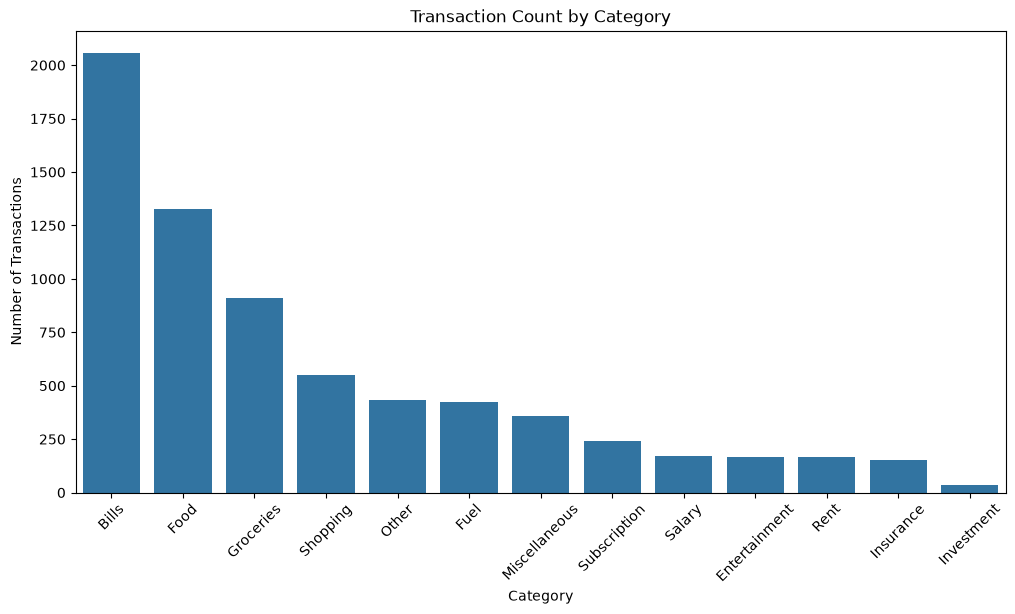

In [28]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="category",
    order=df["category"].value_counts().index
)

plt.title("Transaction Count by Category")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

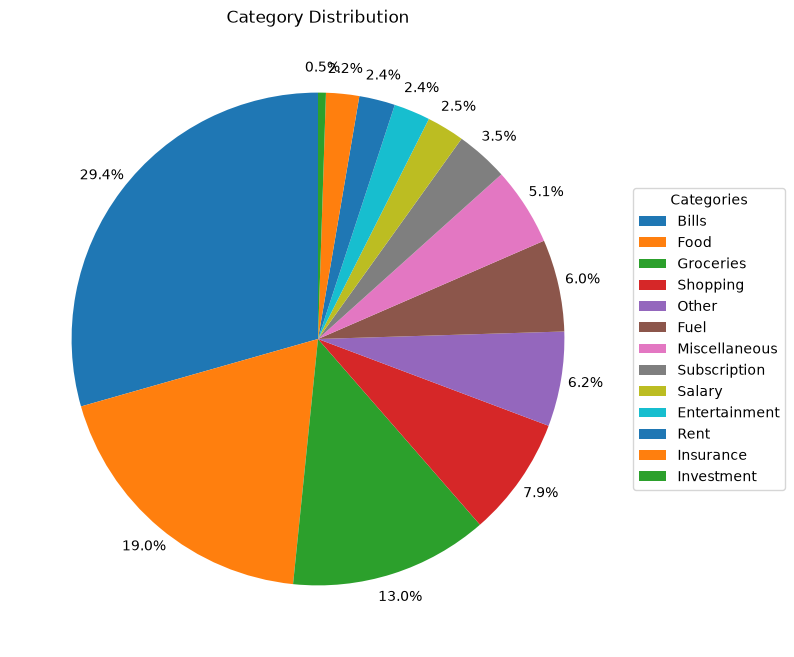

In [29]:
plt.figure(figsize=(8,8))

category_count.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
     labels=None ,
     pctdistance=1.1
)

plt.ylabel("")
plt.legend(category_count.index, title="Categories",
           loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Category Distribution")

plt.show()

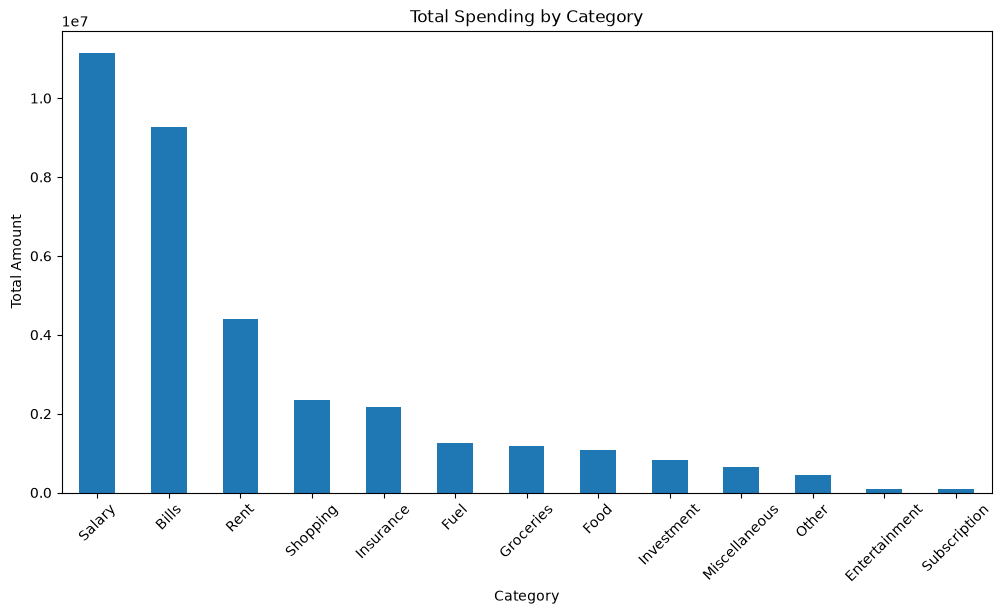

In [30]:
plt.figure(figsize=(12,6))

category_spending.plot(kind="bar")

plt.title("Total Spending by Category")
plt.xlabel("Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)

plt.show()

**Insights:**

* **Most common category:** **Bills** account for the largest share of transactions (**29.4%**), indicating they are the most frequent expense category.
* **Least common category:** **Investment** contributes the smallest share (**0.5%**), making it the least frequent category.
* **Highest spending category:** Based on this distribution, **Bills** represent the largest proportion of expenses (**29.4%**), followed by **Food** (**19.0%**) and **Groceries** (**13.0%**).
* Overall, spending is concentrated in essential expenses such as **Bills, Food, and Groceries**, while categories like **Insurance** and **Investment** contribute only a small percentage.

C:\Users\hp\AppData\Local\Temp\ipykernel_12064\2743356717.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_spending.values, y=avg_spending.index, palette='coolwarm')


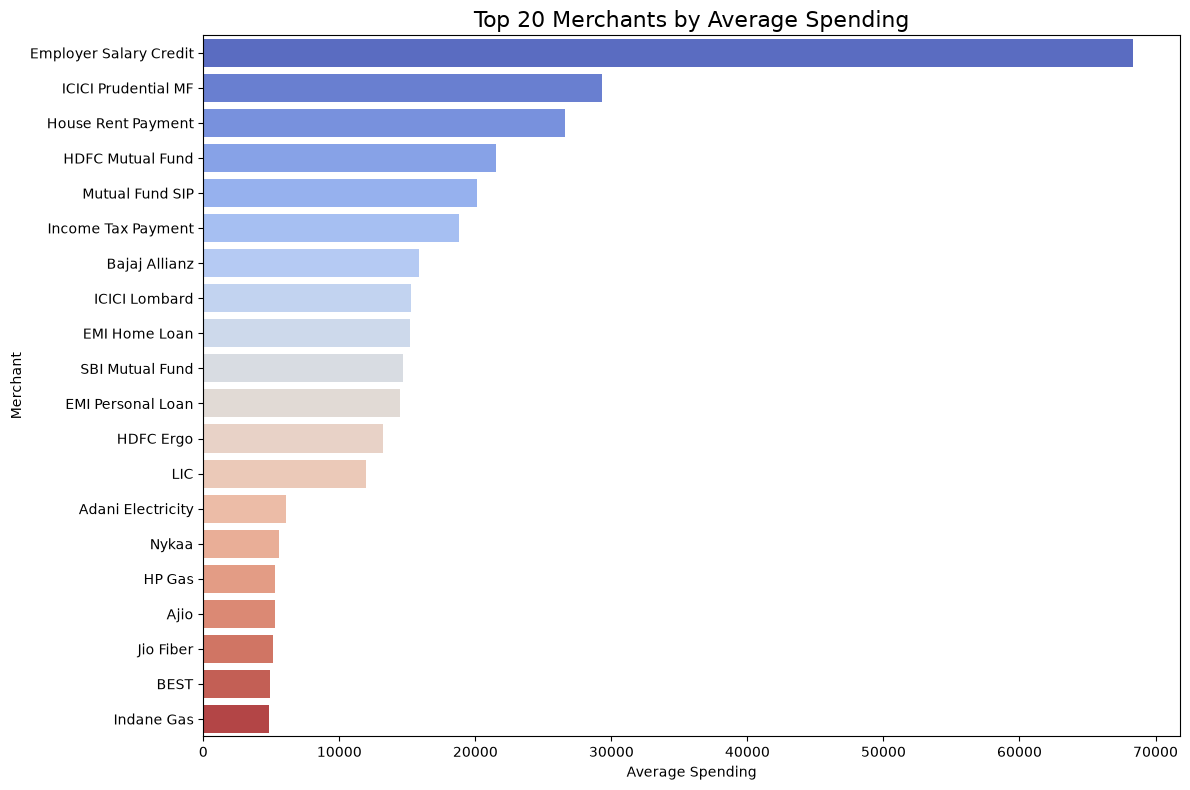

In [31]:
# Number of transactions for each merchant
avg_spending = df.groupby('merchant')['amount'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(12,8))
sns.barplot(x=avg_spending.values, y=avg_spending.index, palette='coolwarm')

plt.title("Top 20 Merchants by Average Spending", fontsize=16)
plt.xlabel("Average Spending")
plt.ylabel("Merchant")
plt.tight_layout()
plt.show()

In [32]:
merchant_average = (
    df.groupby("merchant")["amount"]
      .mean()
      .sort_values(ascending=False)
)

top_merchants = merchant_average.head(20)

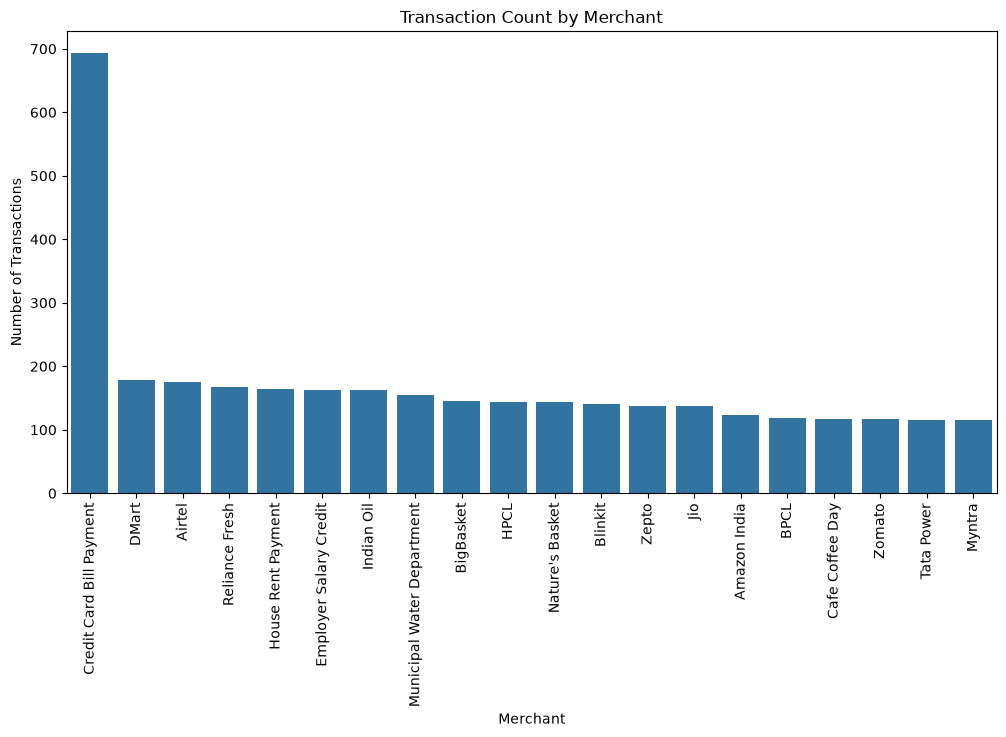

In [33]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="merchant",
    order=df["merchant"].value_counts().head(20).index
)

plt.title("Transaction Count by Merchant")
plt.xlabel("Merchant")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=90)

plt.show()


In [34]:
df.columns

Index(['Unnamed: 0', 'transaction_id', 'transaction_date', 'transaction_time',
       'merchant', 'description', 'amount', 'currency', 'payment_method',
       'transaction_type', 'category', 'city', 'state', 'country'],
      dtype='str')

In [35]:
df.transaction_type.unique()

<StringArray>
['Debit', 'Credit']
Length: 2, dtype: str

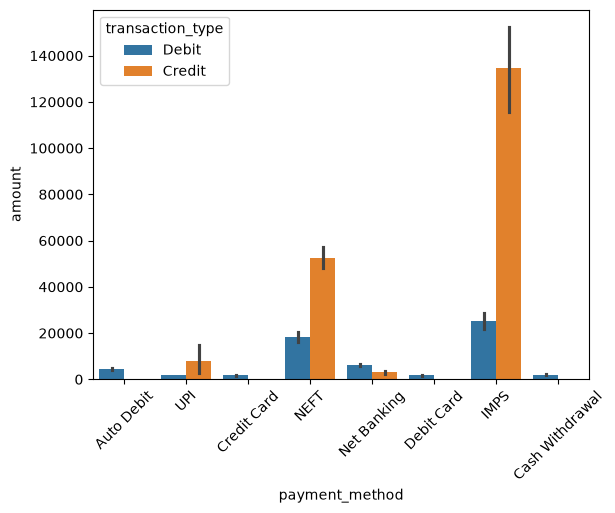

In [36]:
sns.barplot(
    data=df,
    x="payment_method",
    y = "amount" , 
    hue="transaction_type" , 
    errorbar=('ci', 90) ,
    estimator=np.mean

)
plt.xticks(rotation=45)
plt.show()

In [37]:
df.dtypes

Unnamed: 0                   int64
transaction_id                 str
transaction_date    datetime64[us]
transaction_time               str
merchant                       str
description                    str
amount                     float64
currency                       str
payment_method                 str
transaction_type               str
category                       str
city                           str
state                          str
country                        str
dtype: object

In [38]:
df['day'] = df['transaction_date'].dt.day_name()
df['month'] = df['transaction_date'].dt.month_name()
df['year'] = df['transaction_date'].dt.year
df['weekday'] = df['transaction_date'].dt.weekday

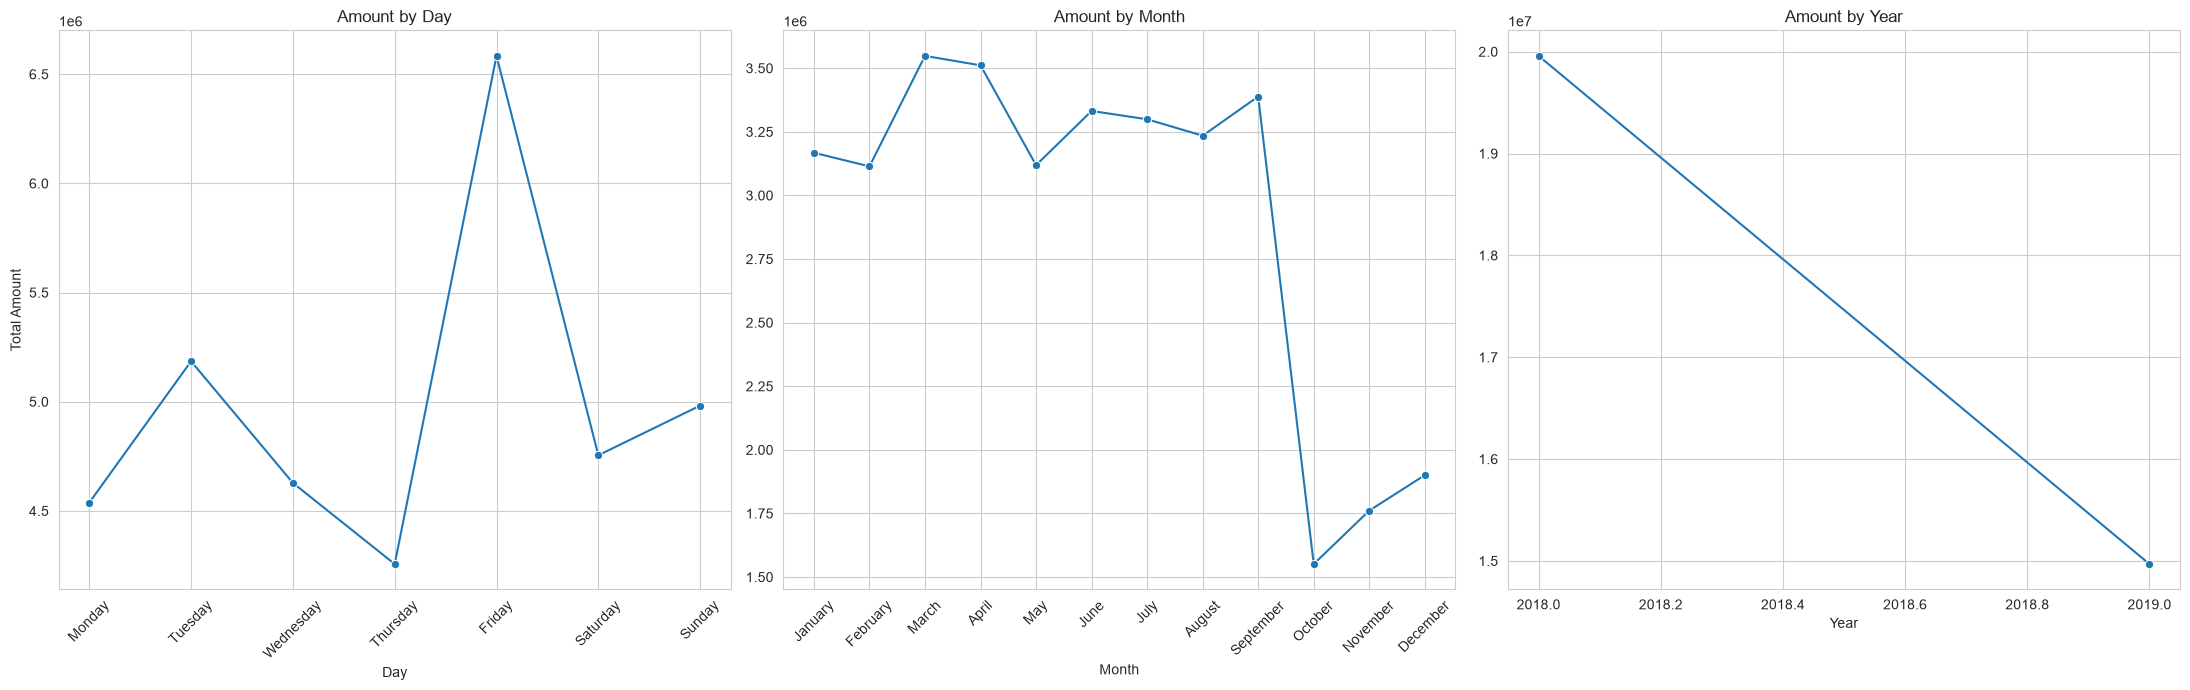

In [39]:
# Set style
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 1. Amount by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_trend = df.groupby('day')['amount'].sum().reindex(day_order)

sns.lineplot(x=day_trend.index, y=day_trend.values, marker='o', ax=axes[0])
axes[0].set_title('Amount by Day')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Total Amount')
axes[0].tick_params(axis='x', rotation=45)

# 2. Amount by Month
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_trend = df.groupby('month')['amount'].sum().reindex(month_order)

sns.lineplot(x=month_trend.index, y=month_trend.values, marker='o', ax=axes[1])
axes[1].set_title('Amount by Month')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)

# 3. Amount by Year
year_trend = df.groupby('year')['amount'].sum()

sns.lineplot(x=year_trend.index, y=year_trend.values, marker='o', ax=axes[2])
axes[2].set_title('Amount by Year')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.show()